# Joint fit of the four-mode Gridium Hamiltonian

This notebook fits one shared handwritten four-mode Hamiltonian to the two
measured KITE-flux sweeps:

- `phi0`: fixed main-loop flux $\varphi_{\rm ext}=0$,
- `phipi`: fixed main-loop flux $\varphi_{\rm ext}=\pi$.

The workflow is deliberately hierarchical:

1. sanitize and flux-calibrate each measured map;
2. link positive ridges, then reconstruct the lower V across its signal-sign
   changes;
3. assign continuous bright $0\to k$ and thermally populated $1\to k$ transitions;
4. fit related parameter groups at inexpensive cutoffs;
5. add both lower-V arms as guarded physical constraints;
6. correct the preview optimization against an intermediate basis;
7. rebalance the fit against the worst retained branches without sacrificing
   either flux cut or the lower V;
8. validate every retained measured point directly at the intermediate basis;
9. overlay the resulting simulated bright transitions on both measurements.

The final metrics use all points in the retained branches, not only the sparse
points used by the optimizer.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "Circuit_Objs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "Circuit_Objs").exists():
    raise RuntimeError("Run this notebook from inside the 2q_gridium repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from tmp.four_mode_gkp_fitting.four_mode_fit import (
    FIT_PROFILES,
    INTERMEDIATE_CUTOFFS,
    JOINT_PARAMETER_BOUNDS,
    TWO_CUT_FIGURE_PATH,
    TWO_CUT_OVERLAY_PATH,
    TWO_CUT_SUMMARY_PATH,
    extract_lower_v_branches,
    prepare_two_cut_experiments,
    run_two_cut_full_workflow,
)

summary = json.loads(TWO_CUT_SUMMARY_PATH.read_text())
cuts = prepare_two_cut_experiments()
cut_by_name = {cut.name: cut for cut in cuts}
with np.load(TWO_CUT_OVERLAY_PATH, allow_pickle=False) as saved:
    overlay = {name: saved[name] for name in saved.files}

print("Repository:", ROOT)
print("Fit summary:", TWO_CUT_SUMMARY_PATH)
print("Final overlay:", TWO_CUT_FIGURE_PATH)

Repository: /Users/eric_jin/2q_gridium-main
Fit summary: /Users/eric_jin/2q_gridium-main/tmp/four_mode_gkp_fitting/two_cut_fit_summary.json
Final overlay: /Users/eric_jin/2q_gridium-main/tmp/four_mode_gkp_fitting/two_cut_fit_overlay.png


## Data provenance and flux coordinates

The two files below are the current working files in `tmp/four_mode_gkp_fitting/data`.
Their SHA-256 hashes are checked against the hashes saved by the fit, so this
report cannot silently substitute an older file.

For each cut, the reflection center $I_c$ is mapped to the protected KITE-flux
coordinate $\vartheta_{\rm ext}=\pi$:

$$
\vartheta_{\rm ext}(I)
=\pi+\pi\frac{I-I_c}{I_{1/2}}.
$$

The symmetric crop uses the same half-period $I_{1/2}=153\,\mu{\rm A}$ on both
sides, so the retained endpoints map to $0$ and $2\pi$.

In [2]:
manifest_rows = []
saved_cuts = {record["name"]: record for record in summary["cuts"]}
for cut in cuts:
    record = saved_cuts[cut.name]
    live_hash = hashlib.sha256(cut.source_path.read_bytes()).hexdigest()
    assert live_hash == record["source_sha256"], (
        f"{cut.name} changed after the fit was generated"
    )
    manifest_rows.append(
        {
            "cut": cut.name,
            "fixed phi_ext": "0" if cut.phi_ext == 0 else "pi",
            "file": cut.source_path.name,
            "SHA-256": live_hash[:16] + "...",
            "current points": cut.spectrum.current_uA.size,
            "frequency points": cut.spectrum.frequency_GHz.size,
            "symmetry center (uA)": cut.symmetry_center_uA,
            "half-period (uA)": cut.half_period_uA,
            "positive tracks": len(cut.tracks),
        }
    )

manifest = pd.DataFrame(manifest_rows).set_index("cut")
display(manifest)

,fixed phi_ext,file,SHA-256,current points,frequency points,symmetry center (uA),half-period (uA),positive tracks
cut,,,,,,,,
phi0,0,Gridium_v4_1_x2y7_GKP1_phi0_theta_sweep.txt,094775bf8d0ef95a...,103,1381,188.0,153.0,35
phipi,pi,Gridium_v4_1_x2y7_GKP1_phipi_theta_sweep.txt,2754c7d2e0b2d907...,103,1381,172.0,153.0,35


## The two measured spectra

An all-NaN endpoint is removed before analysis, isolated missing samples are
interpolated along frequency, and each map is cropped symmetrically around its
own reflection center. These are the two experimental maps actually supplied
to branch extraction and fitting.

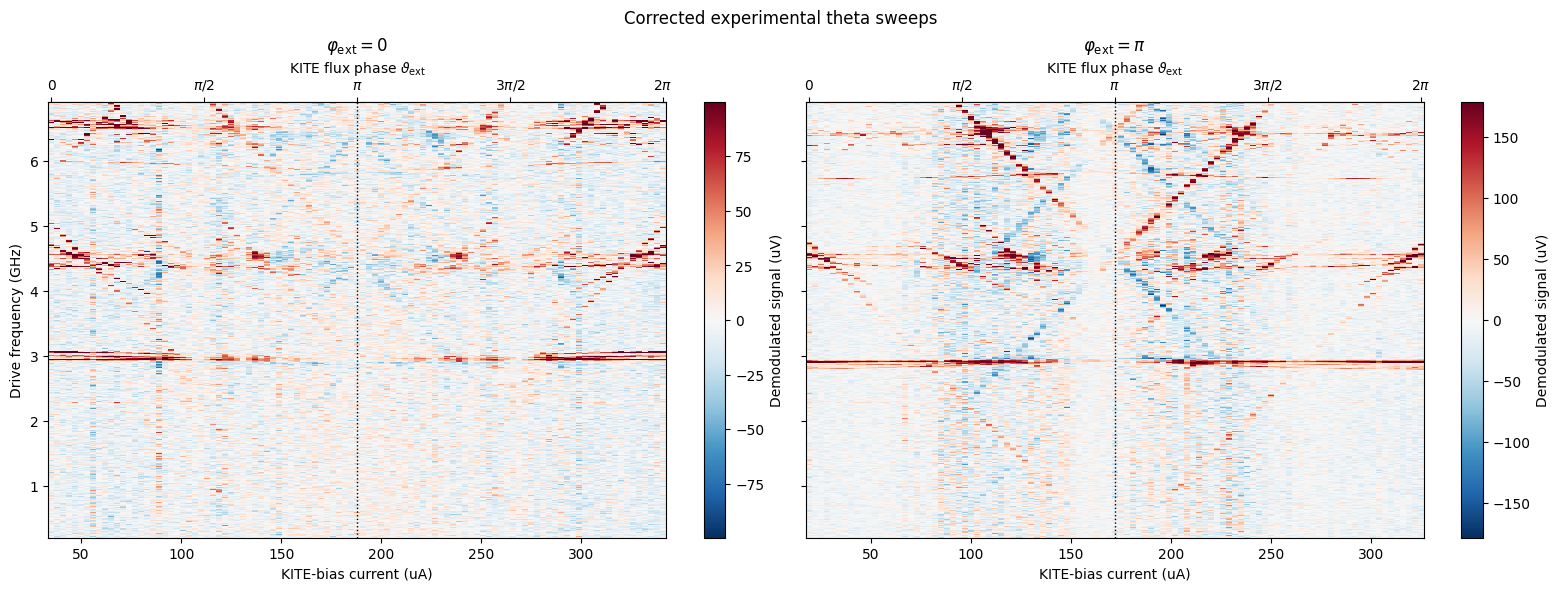

In [3]:
def add_theta_axis(axis, cut):
    center = cut.symmetry_center_uA
    half_period = cut.half_period_uA
    forward = lambda current: np.pi + np.pi * (current - center) / half_period
    inverse = lambda theta: center + half_period * (theta - np.pi) / np.pi
    top = axis.secondary_xaxis("top", functions=(forward, inverse))
    top.set_xticks(
        [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
        ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
    )
    top.set_xlabel(r"KITE flux phase $\vartheta_{\rm ext}$")


fig, axes = plt.subplots(
    1, 2, figsize=(15.5, 5.8), sharey=True, constrained_layout=True
)
for axis, cut in zip(axes, cuts):
    limit = np.nanpercentile(np.abs(cut.spectrum.signal_uV), 99.5)
    mesh = axis.pcolormesh(
        cut.spectrum.current_uA,
        cut.spectrum.frequency_GHz,
        cut.spectrum.signal_uV.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        rasterized=True,
    )
    axis.axvline(cut.symmetry_center_uA, color="black", ls=":", lw=1)
    axis.set(
        xlabel="KITE-bias current (uA)",
        title=(
            r"$\varphi_{\rm ext}=0$"
            if cut.name == "phi0"
            else r"$\varphi_{\rm ext}=\pi$"
        ),
        ylim=(0.2, 6.9),
    )
    add_theta_axis(axis, cut)
    fig.colorbar(mesh, ax=axis, label="Demodulated signal (uV)")
axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("Corrected experimental theta sweeps")
plt.show()

## Ridge extraction, including the lower V

The extraction first removes the slowly varying frequency background and
estimates the local noise. It keeps only positive peaks above the height and
prominence thresholds. A continuity-constrained assignment then links nearby
peaks across current into ridge tracks. Most retained branches are positive
peaks. The lower V in the `phipi` map changes demodulated-signal sign, so it is
reconstructed separately from all-polarity detections and reflection symmetry.
Green curves are positive tracks and purple curves are the two measured V arms;
no simulated line appears in this figure.

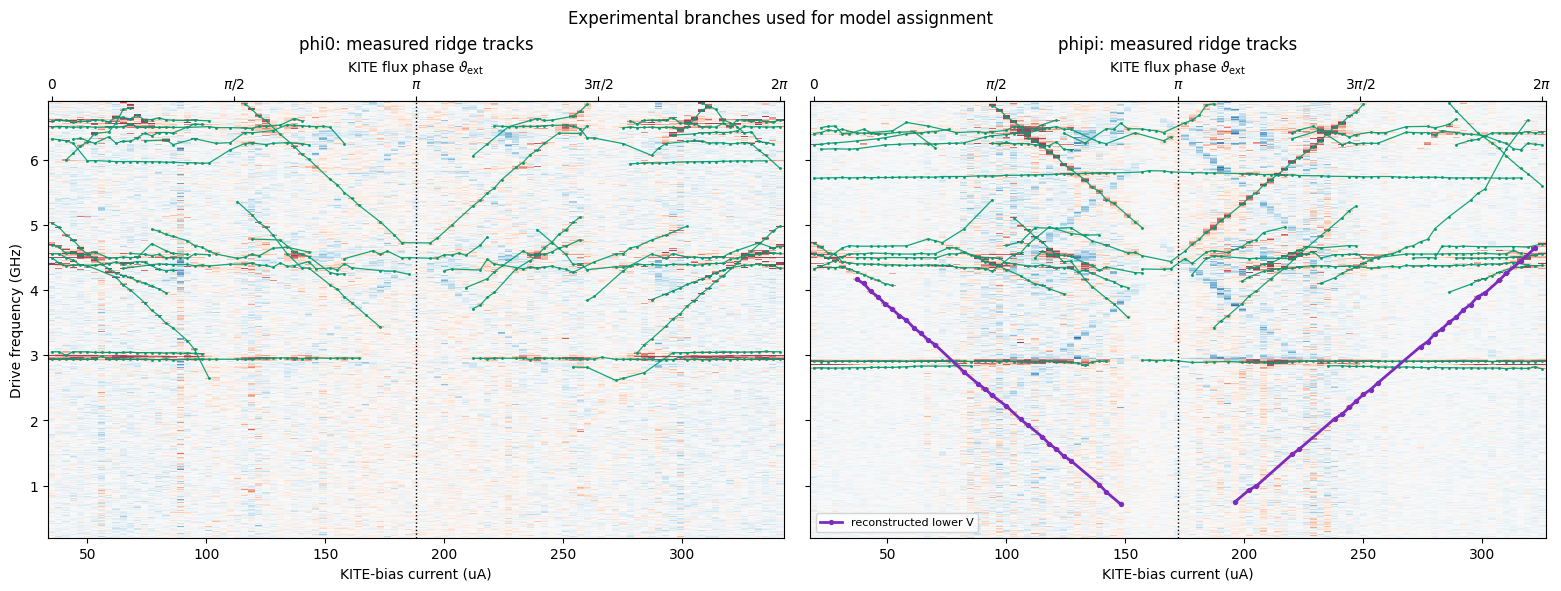

Lower-V extraction: {'source_left_track_id': 14, 'source_right_track_ids': [36, 41], 'reflection_rms_MHz': [18.448770768187888, 25.217801252290112], 'left_points': 27, 'right_points': 26, 'left_polarities': [-1, 1], 'right_polarities': [-1, 1]}


In [4]:
fig, axes = plt.subplots(
    1, 2, figsize=(15.5, 5.8), sharey=True, constrained_layout=True
)
for axis, cut in zip(axes, cuts):
    limit = np.nanpercentile(np.abs(cut.spectrum.signal_uV), 99.5)
    axis.pcolormesh(
        cut.spectrum.current_uA,
        cut.spectrum.frequency_GHz,
        cut.spectrum.signal_uV.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        rasterized=True,
        alpha=0.72,
    )
    for track in cut.tracks:
        axis.plot(
            track.currents_uA,
            track.frequencies_GHz,
            color="#009e73",
            lw=0.9,
            marker=".",
            ms=2.2,
            alpha=0.92,
        )
    if cut.name == "phipi":
        lower_v_tracks, lower_v_extraction = extract_lower_v_branches(cut)
        for index, track in enumerate(lower_v_tracks):
            axis.plot(
                track.currents_uA,
                track.frequencies_GHz,
                color="#7b2cbf",
                lw=2.0,
                marker="o",
                ms=2.8,
                label="reconstructed lower V" if index == 0 else None,
            )
        axis.legend(loc="lower left", frameon=True, fontsize=8)
    axis.axvline(cut.symmetry_center_uA, color="black", ls=":", lw=1)
    axis.set(
        xlabel="KITE-bias current (uA)",
        title=f"{cut.name}: measured ridge tracks",
        ylim=(0.2, 6.9),
    )
    add_theta_axis(axis, cut)
axes[0].set_ylabel("Drive frequency (GHz)")
fig.suptitle("Experimental branches used for model assignment")
plt.show()
print("Lower-V extraction:", lower_v_extraction)

## Physical transition assignment

At every hierarchy stage, the current Hamiltonian predicts 15 eigenlevels and
candidate transition frequencies from both thermally relevant origins:

$$
f_{ik}(I)=\frac{E_k(I)-E_i(I)}{h},\qquad i\in\{0,1\}.
$$

The $i=1$ family is required because the lowest doublet splitting is small
compared with the experimental temperature. Candidate paths are scored using
frequency agreement, slope continuity, label-switch penalties, and matrix
elements of four physical drive operators. Frequency-band quotas keep low,
middle, and high branches represented instead of letting one dense horizontal
family dominate the fit.

The two lower-V arms are assigned as one named branch family. Their points are
weighted in the fit even when their demodulated signal is negative, and a final
quality check requires both arms to remain present.

## Hierarchical parameter fit

The Hamiltonian parameters are shared by both cuts. Only the applied value of
$\varphi_{\rm ext}$ differs. Each stage holds the current branch labels fixed,
computes finite-difference sensitivities, solves a regularized Gauss-Newton
step, and accepts a line-search step only when it improves the robust joint
score without materially degrading either cut.

The inexpensive stages successively fit global/inductive, nonlinear/charging,
and KITE-asymmetry groups. A joint refinement follows, then a guarded stage
introduces both lower-V arms. In the default `preview` profile, the optimizer
uses the preview basis and a final multifidelity stage measures its shift at
the intermediate basis, corrects the parameters, and validates every retained
point there. The optional `production` profile adds a branch-balance search
that targets the worst retained ridge without degrading either flux cut.

In [5]:
stage_rows = []
for stage in summary["stages"]:
    name = stage["name"]
    if stage.get("iterations"):
        last = stage["iterations"][-1]
        metrics = last.get("accepted_metrics", last.get("baseline_metrics", {}))
        if stage.get("authoritative_accepted"):
            accepted_fraction = stage["authoritative_accepted_fraction"]
            accepted_record = next(
                record
                for record in stage["authoritative_line_search"]
                if record["accepted"]
                and np.isclose(record["fraction"], accepted_fraction)
            )
            metrics = accepted_record["metrics"]
        active = ", ".join(last.get("active_parameters", []))
        tracks = last.get("assigned_tracks_by_cut", {})
        cutoffs = stage.get("cutoffs", {})
    else:
        update = stage.get("update", {})
        metrics = update.get("accepted_metrics", {})
        active = ", ".join(update.get("active_parameters", []))
        tracks = {}
        cutoffs = stage.get("correction_and_validation_cutoffs", {})
    combined = metrics.get("combined", {})
    stage_rows.append(
        {
            "stage": name,
            "active parameters": active,
            "basis (n1,N2,N3,N4,nkeep)": (
                cutoffs.get("n1max"),
                cutoffs.get("N2"),
                cutoffs.get("N3"),
                cutoffs.get("N4"),
                cutoffs.get("nkeep"),
            ),
            "selected tracks phi0/phipi": (
                f'{tracks.get("phi0", "-")}/{tracks.get("phipi", "-")}'
            ),
            "accepted joint RMS (MHz)": combined.get("rms_MHz", np.nan),
        }
    )

stage_table = pd.DataFrame(stage_rows).set_index("stage")
display(stage_table.style.format({"accepted joint RMS (MHz)": "{:.1f}"}))

,active parameters,"basis (n1,N2,N3,N4,nkeep)",selected tracks phi0/phipi,accepted joint RMS (MHz)
stage,,,,
coarse_inductive_and_global,"EJ, EL, ELK, eP","(2, 21, 21, 5, 30)",18/18,151.8
coarse_nonlinear_and_charging,"EC, EJS, ECS, eC","(2, 21, 21, 5, 30)",18/18,141.3
coarse_kite_asymmetry,"eps_J, eps_LK","(2, 21, 21, 5, 30)",17/18,145.2
medium_joint_refinement,"EJ, EC, EL, ELK, EJS, ECS, eC, eP, eps_J, eps_LK","(3, 25, 25, 6, 40)",18/18,91.1
production_joint_refinement,"EJ, EC, EL, ELK, EJS, ECS, eC, eP, eps_J, eps_LK","(3, 31, 31, 8, 60)",18/18,98.6
production_confirmation_refinement,"EJ, EC, EL, ELK, ECS, eC, eP","(3, 31, 31, 8, 60)",18/18,96.3
lower_v_guarded_refinement,"EJ, EC, EL, ELK, eC, eP","(3, 31, 31, 8, 60)",19/19,87.8
two_cut_multifidelity_correction,"EJ, EC, EL, ELK, ECS, eC, eP","(4, 51, 51, 8, 120)",-/-,140.8
intermediate_branch_balance_refinement,"EJ, EC, EL, ELK, EJS, ECS, eC, eP, eps_J, eps_LK","(4, 51, 51, 8, 120)",19/20,128.3


## Extracted Hamiltonian parameters

All energies are reported as frequencies in GHz. The two inductive energies
$E_L$ and $E_{LK}$ are fitted independently. The offset charge is fixed at
$n_g=0$. The fitted asymmetries are fractional arm imbalances rather than
energies.

In [6]:
descriptions = {
    "EJ": "KITE-arm Josephson energy",
    "EC": "KITE-arm charging energy",
    "EL": "main-loop inductive energy",
    "ELK": "KITE-loop inductive energy",
    "EJS": "side-junction Josephson energy",
    "ECS": "side-junction charging energy",
    "eC": "four-mode charging coefficient eC",
    "eP": "four-mode charging coefficient eP",
    "eps_J": "fractional Josephson-arm asymmetry",
    "eps_LK": "fractional inductive-arm asymmetry",
    "ng": "offset charge (fixed)",
}
starting = summary["starting_parameters_GHz"]
final = summary["final_parameters_GHz"]
parameter_rows = []
for name, value in final.items():
    bounds = JOINT_PARAMETER_BOUNDS.get(name)
    parameter_rows.append(
        {
            "parameter": name,
            "description": descriptions[name],
            "starting value": starting.get(name, np.nan),
            "fitted value": value,
            "change": value - starting.get(name, value),
            "allowed bounds": bounds if bounds is not None else "fixed",
            "unit": "fraction" if name.startswith("eps_") else (
                "dimensionless" if name == "ng" else "GHz"
            ),
        }
    )

parameter_table = pd.DataFrame(parameter_rows).set_index("parameter")
display(
    parameter_table.style.format(
        {"starting value": "{:.6f}", "fitted value": "{:.6f}", "change": "{:+.6f}"}
    )
)

,description,starting value,fitted value,change,allowed bounds,unit
parameter,,,,,,
EC,KITE-arm charging energy,0.770000,0.795262,+0.025262,"(0.35, 1.5)",GHz
ECS,side-junction charging energy,8.130000,8.182604,+0.052604,"(4.0, 14.0)",GHz
EJ,KITE-arm Josephson energy,8.502792,8.543963,+0.041171,"(5.0, 12.0)",GHz
EJS,side-junction Josephson energy,1.130000,1.159885,+0.029885,"(0.4, 3.0)",GHz
EL,main-loop inductive energy,0.488034,0.527232,+0.039198,"(0.2, 1.2)",GHz
ELK,KITE-loop inductive energy,0.488034,0.507323,+0.019288,"(0.2, 1.2)",GHz
eC,four-mode charging coefficient eC,0.700000,0.699228,-0.000772,"(0.3, 2.0)",GHz
eP,four-mode charging coefficient eP,1.359255,1.389295,+0.030040,"(0.5, 2.8)",GHz
eps_J,fractional Josephson-arm asymmetry,0.000000,-0.000038,-0.000038,"(-0.2, 0.2)",fraction


## Final all-point fit quality

The optimizer uses sparse points for speed, but these statistics are recomputed
from every point in all retained tracks. The residual is
$f_{\rm simulation}-f_{\rm measured}$. The two cuts have comparable errors,
which is important: a low combined number would be misleading if one flux cut
were sacrificed to fit the other.

In [7]:
metric_table = pd.DataFrame(summary["final_metrics"]).T
metric_table.index.name = "data set"
display(
    metric_table.style.format(
        {
            "points": "{:.0f}",
            "rms_MHz": "{:.2f}",
            "median_absolute_MHz": "{:.2f}",
            "p90_absolute_MHz": "{:.2f}",
            "fraction_within_100_MHz": "{:.1%}",
        }
    )
)

assignment_counts = pd.DataFrame(
    [
        {
            "cut": name,
            "tracks": sum(row["cut_name"] == name for row in summary["final_assignments"]),
            "measured points": sum(
                len(row["observed_GHz"])
                for row in summary["final_assignments"]
                if row["cut_name"] == name
            ),
        }
        for name in ("phi0", "phipi")
    ]
).set_index("cut")
display(assignment_counts)

quality = summary["quality_gate"]
display(
    pd.DataFrame([quality["lower_v_metrics"]], index=["lower V"]).style.format(
        {
            "points": "{:.0f}",
            "tracks": "{:.0f}",
            "rms_MHz": "{:.2f}",
            "median_absolute_MHz": "{:.2f}",
            "fraction_within_100_MHz": "{:.1%}",
        }
    )
)

track_records = quality["per_track_metrics"]["records"]
track_table = pd.DataFrame(track_records).sort_values(
    ["rms_MHz", "cut_name"], ascending=[False, True]
)
display(
    track_table[
        [
            "cut_name", "track_id", "track_role", "points", "rms_MHz",
            "maximum_absolute_MHz", "fraction_within_100_MHz",
        ]
    ].style.format(
        {
            "points": "{:.0f}",
            "rms_MHz": "{:.2f}",
            "maximum_absolute_MHz": "{:.2f}",
            "fraction_within_100_MHz": "{:.1%}",
        }
    )
)
display(
    pd.DataFrame(
        {
            "passed": quality["checks"],
        }
    ).rename_axis("declared quality check")
)
assert quality["passed"], "Saved fit does not pass the declared two-cut gate."

,fraction_within_100_MHz,median_absolute_MHz,p90_absolute_MHz,points,rms_MHz
data set,,,,,
combined,92.0%,35.86,94.52,915,62.57
phi0,91.5%,35.62,95.25,412,64.60
phipi,92.4%,36.47,93.62,503,60.85


,tracks,measured points
cut,,
phi0,19,412
phipi,20,503


,fraction_within_100_MHz,median_absolute_MHz,points,rms_MHz,tracks
lower V,100.0%,47.58,53,51.09,2


,cut_name,track_id,track_role,points,rms_MHz,maximum_absolute_MHz,fraction_within_100_MHz
5,phi0,6,positive_ridge,28,142.94,293.49,67.9%
28,phipi,14,positive_ridge,19,141.06,418.51,73.7%
22,phipi,4,positive_ridge,32,95.50,185.95,68.8%
35,phipi,29,positive_ridge,12,94.23,169.01,66.7%
26,phipi,9,positive_ridge,19,84.77,176.35,68.4%
4,phi0,5,positive_ridge,17,84.18,154.16,70.6%
18,phi0,32,positive_ridge,17,79.86,165.25,76.5%
13,phi0,27,positive_ridge,18,77.74,174.60,77.8%
25,phipi,8,positive_ridge,28,74.87,126.46,89.3%
21,phipi,3,positive_ridge,16,71.33,178.64,87.5%


,passed
declared quality check,
both_lower_v_arms_retained,True
coverage_above_limit_for_each_cut,True
enough_retained_tracks_for_each_cut,True
every_track_rms_below_limit,True
lower_v_rms_below_limit,True
rms_below_limit_for_each_cut,True


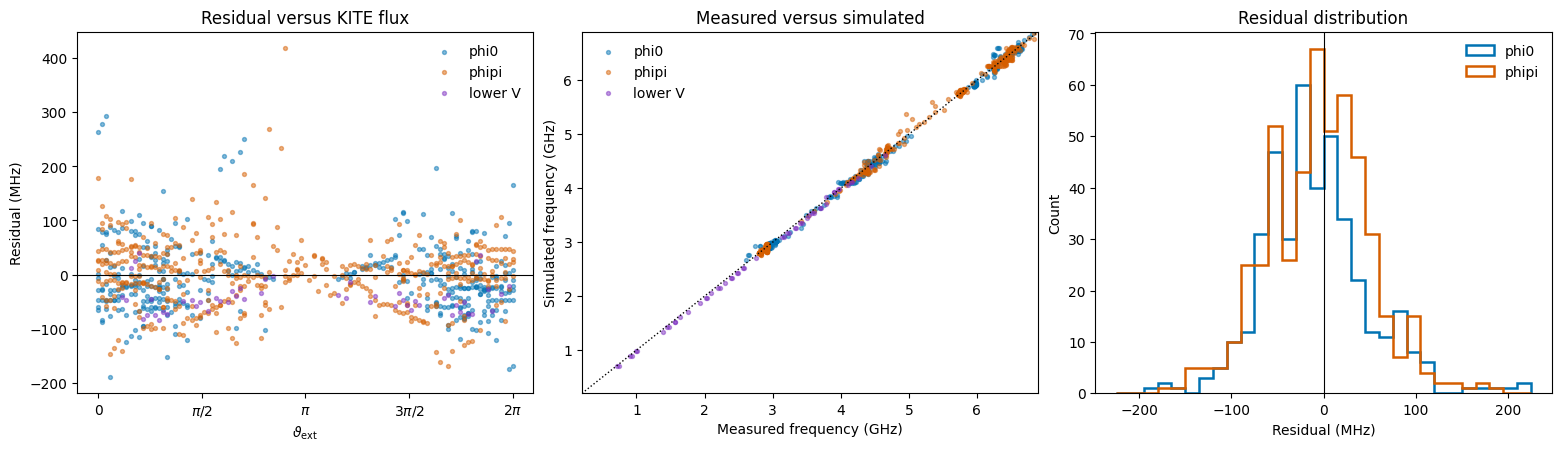

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4), constrained_layout=True)
colors = {"phi0": "#0072b2", "phipi": "#d55e00"}
all_residuals = []

for name in ("phi0", "phipi"):
    cut = cut_by_name[name]
    cut_residuals = []
    for row in summary["final_assignments"]:
        if row["cut_name"] != name:
            continue
        current = np.asarray(row["current_uA"])
        theta = np.pi + np.pi * (
            current - cut.symmetry_center_uA
        ) / cut.half_period_uA
        residual = np.asarray(row["residual_MHz"])
        observed = np.asarray(row["observed_GHz"])
        predicted = np.asarray(row["predicted_GHz"])
        is_lower_v = row.get("track_role", "").startswith("lower_v_")
        color = "#7b2cbf" if is_lower_v else colors[name]
        label = "lower V" if is_lower_v else name
        axes[0].scatter(theta, residual, s=8, alpha=0.48, color=color, label=label)
        axes[1].scatter(observed, predicted, s=8, alpha=0.48, color=color, label=label)
        cut_residuals.extend(residual)
        all_residuals.extend(residual)
    axes[2].hist(
        cut_residuals,
        bins=np.arange(-225, 226, 15),
        histtype="step",
        lw=1.8,
        color=colors[name],
        label=name,
    )

axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xticks(
    [0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi],
    ["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"],
)
axes[0].set(xlabel=r"$\vartheta_{\rm ext}$", ylabel="Residual (MHz)", title="Residual versus KITE flux")

limits = [0.2, 6.9]
axes[1].plot(limits, limits, color="black", ls=":", lw=1)
axes[1].set(
    xlim=limits,
    ylim=limits,
    xlabel="Measured frequency (GHz)",
    ylabel="Simulated frequency (GHz)",
    title="Measured versus simulated",
)
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set(xlabel="Residual (MHz)", ylabel="Count", title="Residual distribution")
for axis in axes:
    handles, labels = axis.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    axis.legend(unique.values(), unique.keys(), frameon=False)
plt.show()

## Final simulation over both experimental maps

Faint green and gold curves are all matrix-element-visible simulated
$0\to k$ and $1\to k$ transitions. Bright green paths with circles are the
continuous model branches assigned to positive ridges. Purple paths are the
fitted lower V, and black crosses are measured ridge points. The dotted line marks
$\vartheta_{\rm ext}=\pi$ for each independently calibrated cut.

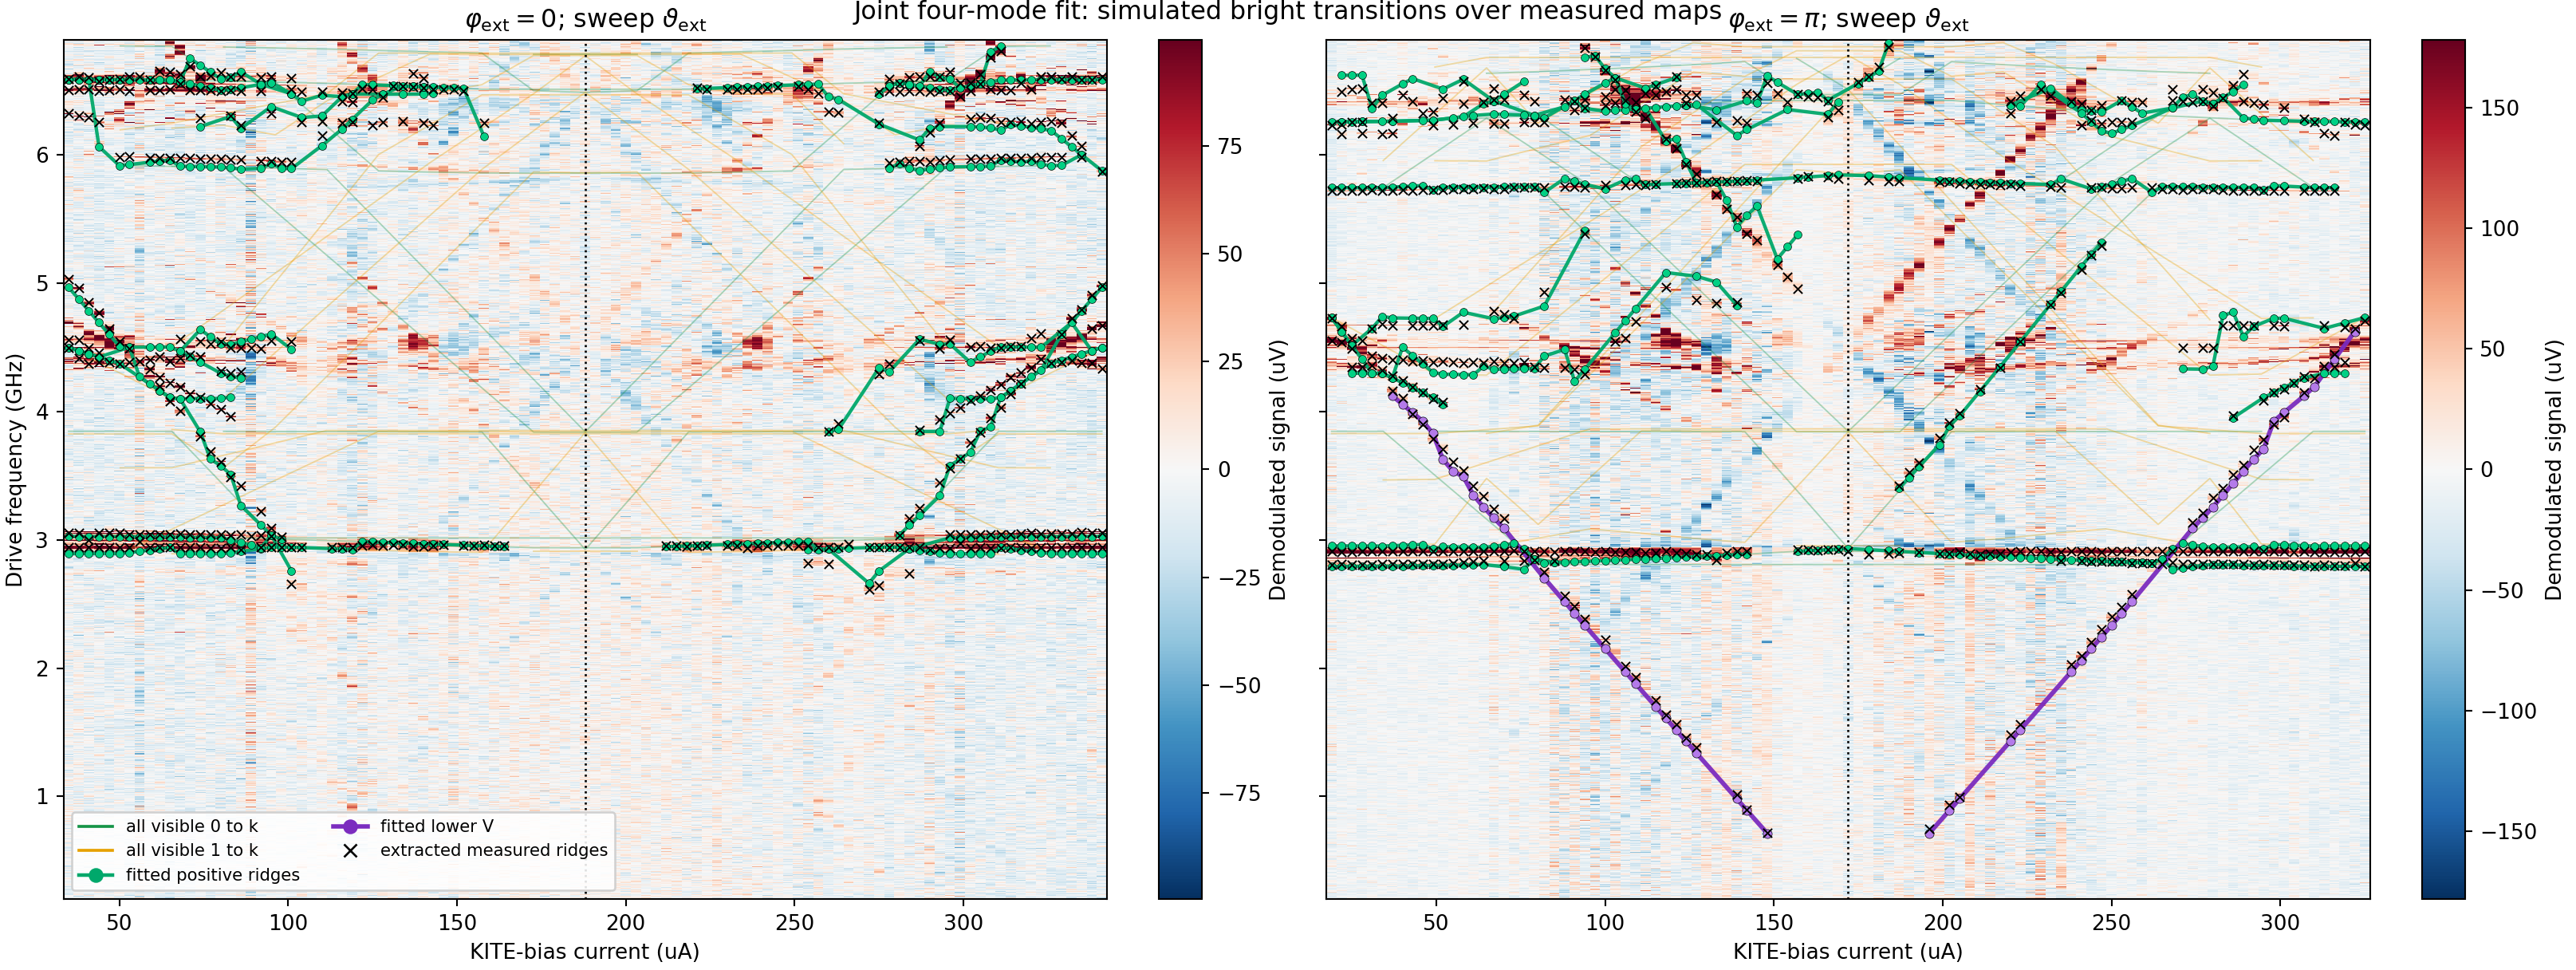

In [9]:
display(Image(filename=str(TWO_CUT_FIGURE_PATH)))

## Cutoff control

The default optimizer uses the preview basis. Its accepted parameters are then
corrected and reassigned at the intermediate basis, which is also used for the
reported all-point validation and overlay. Selecting the `intermediate` profile
instead runs every optimizer evaluation at that larger basis and skips the
redundant preview-to-intermediate correction.

This is a numerical control, not evidence that the intermediate basis is the
infinite-cutoff limit. The fitted values should therefore be treated as the
best shared intermediate-validated parameter estimate; publishable parameter
uncertainties require a larger-basis convergence study around this optimum.

In [10]:
spot_rows = []
for name, record in summary["cutoff_spot_check"]["cuts"].items():
    spot_rows.append(
        {
            "cut": name,
            "max shift of first six 0->k lines (MHz)": record[
                "maximum_first_six_ground_shift_MHz"
            ],
            "RMS indexed-transition shift (MHz)": record[
                "rms_indexed_transition_shift_MHz"
            ],
            "max indexed-transition shift (MHz)": record[
                "maximum_indexed_transition_shift_MHz"
            ],
        }
    )
display(pd.DataFrame(spot_rows).set_index("cut").style.format("{:.1f}"))

multifidelity = next((
    stage for stage in summary["stages"]
    if stage["name"] == "two_cut_multifidelity_correction"
), None)
if multifidelity is None:
    print(summary.get(
        "multifidelity_skip_reason",
        "No multifidelity correction was applied.",
    ))
else:
    update = multifidelity["update"]
    display(pd.DataFrame({
        "value (MHz)": {
            "correction RMS": update["correction_rms_MHz"],
            "maximum correction": update["correction_maximum_MHz"],
        }
    }).style.format("{:.2f}"))
print("Final combined RMS (MHz):", summary["final_metrics"]["combined"]["rms_MHz"])
print("Optimizer cutoffs:", summary["optimizer_cutoffs"])
print("Final simulation/validation cutoffs:", summary["fit_cutoffs"])
assert summary["fit_cutoffs"] == INTERMEDIATE_CUTOFFS
assert summary["overlay"]["cutoffs"] == INTERMEDIATE_CUTOFFS

,max shift of first six 0->k lines (MHz),RMS indexed-transition shift (MHz),max indexed-transition shift (MHz)
cut,,,
phi0,273.5,242.5,578.3
phipi,264.8,226.5,524.3


,value (MHz)
correction RMS,170.02
maximum correction,482.50


Final combined RMS (MHz): 62.56634287584536
Optimizer cutoffs: {'L2': 11.0, 'L3': 14.0, 'N2': 31, 'N3': 31, 'N4': 8, 'n1max': 3, 'nkeep': 60}
Final simulation/validation cutoffs: {'L2': 11.0, 'L3': 14.0, 'N2': 51, 'N3': 51, 'N4': 8, 'n1max': 4, 'nkeep': 120}


## Reproduce the expensive fit

The saved results above are loaded by default. Set the flag below only when a
full refit is intended. `FIT_PROFILE` is the only accuracy/runtime switch:

- `preview` (default): preview-basis optimization followed by the validated
  intermediate-basis correction and all-point validation;
- `intermediate`: all optimizer evaluations use the intermediate basis and are
  therefore much slower;
- `production`: the preview workflow plus the guarded final branch-balance pass.

In [11]:
RUN_EXPENSIVE_FIT = False
WORKERS = 2
FIT_PROFILE = "preview"  # preview, intermediate, or production
assert FIT_PROFILE in FIT_PROFILES
print("Selected fit profile:", FIT_PROFILE)
print(FIT_PROFILES[FIT_PROFILE])

if RUN_EXPENSIVE_FIT:
    summary = run_two_cut_full_workflow(
        workers=WORKERS,
        overlay_points=21,
        profile=FIT_PROFILE,
    )
    print("Full two-cut fit completed.")
else:
    command = (
        f"{sys.executable} "
        f"{ROOT / 'tmp/four_mode_gkp_fitting/four_mode_fit.py'} "
        f"all --workers {WORKERS} --overlay-points 21 "
        f"--profile {FIT_PROFILE}"
    )
    print("Using the saved validated result.")
    print("Full reproduction command:")
    print(command)

Selected fit profile: preview
FitProfile(name='preview', optimizer_basis='preview', validation_basis='intermediate', use_basis_correction=True, run_branch_balance=False, run_refined_spot_check=False)
Using the saved validated result.
Full reproduction command:
/Users/eric_jin/.pyenv/versions/3.11.9/bin/python /Users/eric_jin/2q_gridium-main/tmp/four_mode_gkp_fitting/four_mode_fit.py all --workers 2 --overlay-points 21 --profile preview


## Simulated spectrum on the measured axes

The fitted Hamiltonian re-plotted over the same two flux sweeps, on identical axes, limits and KITE-flux phase scale as the measured maps above, so the two can be compared directly. Line colour encodes the relative drive matrix element, so transitions the drive cannot reach appear dark; solid lines start from the ground state and dashed lines from the thermally populated first excited state. Values come from the overlay bundle written by the fit, so this cell re-plots rather than re-solving.

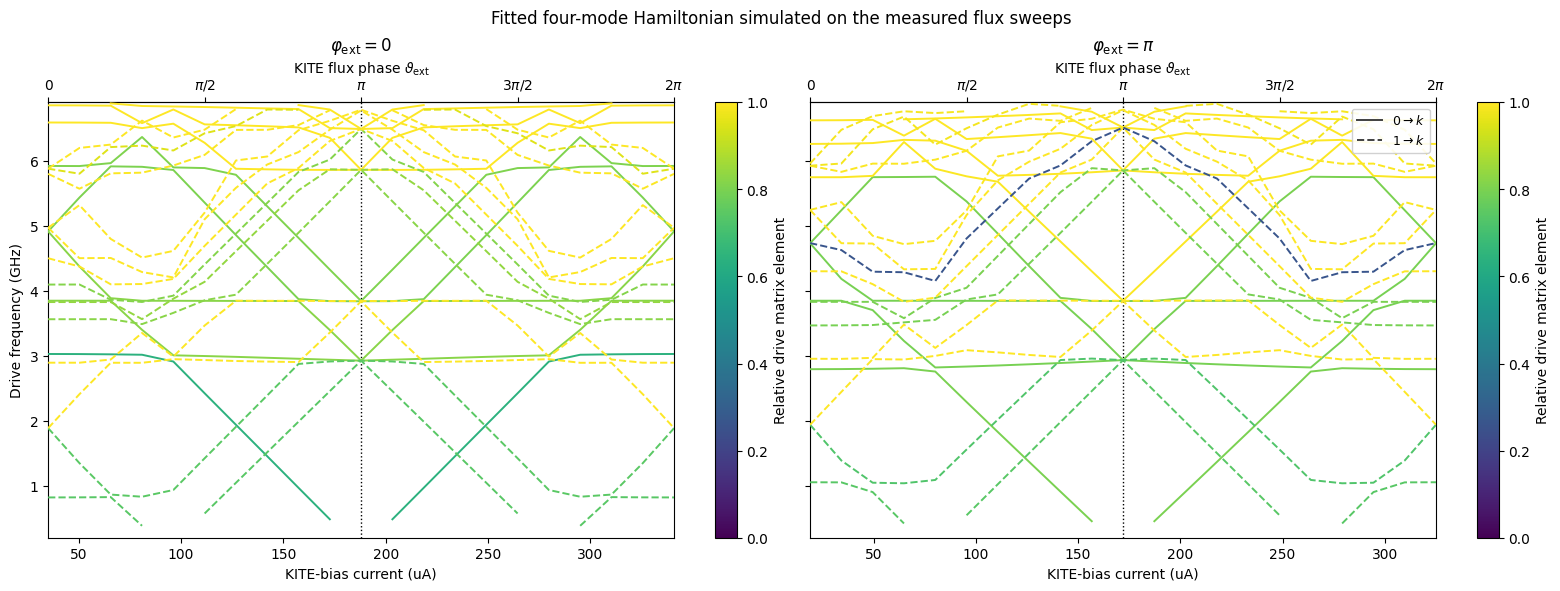

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Simulated spectrum of the fitted Hamiltonian on the same two flux sweeps.
# Everything is read from the overlay bundle produced by the fit, so this cell
# re-plots rather than re-solving.  Axes, limits, theta axis and figure geometry
# match the measured-map cell above, including the colourbar, so the two figures
# can be compared directly or stacked.
BRIGHTNESS_FLOOR = 0.02          # drop transitions the drive effectively cannot reach
FREQUENCY_LIMITS = (0.2, 6.9)    # identical to the measured maps

brightness_norm = Normalize(vmin=0.0, vmax=1.0)
brightness_cmap = plt.get_cmap("viridis")

fig, axes = plt.subplots(
    1, 2, figsize=(15.5, 5.8), sharey=True, constrained_layout=True
)
for axis, cut in zip(axes, cuts):
    current = overlay[f"{cut.name}_simulation_current_uA"]
    frequencies = overlay[f"{cut.name}_transition_frequencies_GHz"]
    weights = overlay[f"{cut.name}_relative_matrix_element"]
    initial_states = overlay[f"{cut.name}_initial_states"]
    final_states = overlay[f"{cut.name}_final_states"]

    for index in range(frequencies.shape[1]):
        brightness = weights[:, index]
        peak = float(np.nanmax(brightness)) if np.isfinite(brightness).any() else 0.0
        if peak < BRIGHTNESS_FLOOR:
            continue
        line = frequencies[:, index]
        inside = (
            np.isfinite(line)
            & (line >= FREQUENCY_LIMITS[0])
            & (line <= FREQUENCY_LIMITS[1])
        )
        if not inside.any():
            continue
        from_ground = int(initial_states[index]) == 0
        axis.plot(
            current,
            np.where(inside, line, np.nan),
            color=brightness_cmap(brightness_norm(peak)),
            linestyle="-" if from_ground else "--",
            linewidth=1.4,
            zorder=3,
        )

    # Same reference line, limits and secondary axis as the measured maps.
    axis.axvline(cut.symmetry_center_uA, color="black", ls=":", lw=1)
    axis.set(
        xlabel="KITE-bias current (uA)",
        title=(
            r"$\varphi_{\rm ext}=0$"
            if cut.name == "phi0"
            else r"$\varphi_{\rm ext}=\pi$"
        ),
        xlim=(
            float(cut.spectrum.current_uA.min()),
            float(cut.spectrum.current_uA.max()),
        ),
        ylim=FREQUENCY_LIMITS,
    )
    add_theta_axis(axis, cut)
    # Keeps the axes the same width as the measured figure, which carries a
    # colourbar of its own.
    fig.colorbar(
        ScalarMappable(norm=brightness_norm, cmap=brightness_cmap),
        ax=axis,
        label="Relative drive matrix element",
    )

axes[0].set_ylabel("Drive frequency (GHz)")
axes[1].legend(
    handles=[
        Line2D([0], [0], color="0.25", lw=1.4, label=r"$0\rightarrow k$"),
        Line2D([0], [0], color="0.25", lw=1.4, ls="--", label=r"$1\rightarrow k$"),
    ],
    loc="upper right",
    fontsize=9,
    framealpha=0.9,
)
fig.suptitle("Fitted four-mode Hamiltonian simulated on the measured flux sweeps")
plt.show()
